<a href="https://colab.research.google.com/github/ibtihalalf/Sdaia-Bootcamp/blob/main/Week3/M1/ex2_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [2]:
url = 'https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv'
data = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv")
data.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = data['Experience Years']
y = data['Salary']

### Step 2.b print the type of each

In [5]:
print(type(X))
print(type(y))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

the target is numerical and the task is regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40,)
y shape: (40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
data.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

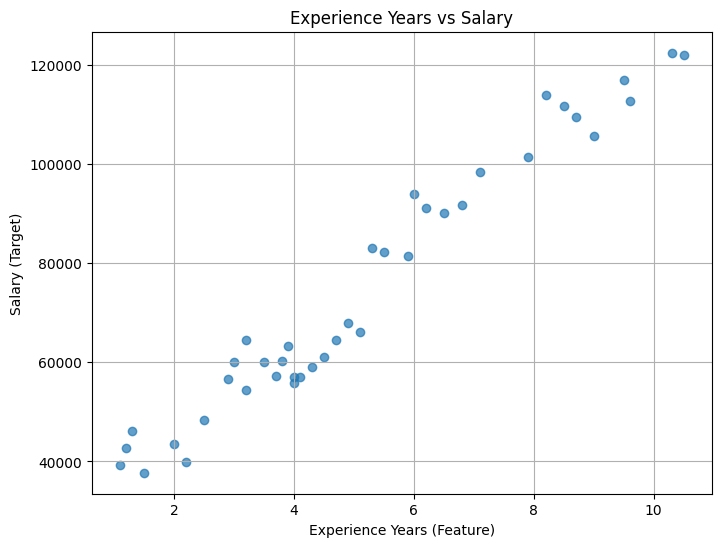

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.7)
plt.title('Experience Years vs Salary')
plt.xlabel('Experience Years (Feature)')
plt.ylabel('Salary (Target)')
plt.grid(True)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

increasing

### Step 7. Initialize a regression model

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

### Step 9.a Train the model on the training set

In [14]:
model.fit(X_train.values.reshape(-1,1), y_train)

LinearRegression()

### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [15]:
print("Slope : " , model.coef_)
print("y-intercept : " , model.intercept_)

Slope :  [9446.28361721]
y-intercept :  26062.331465710435


### Step 9.c how much salary does a person get with 2 years of experience?

In [16]:
model.predict([[2]])

array([44954.89870013])

### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [17]:
print(model.coef_[0] * 0.5)

4723.141808606006


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [18]:
model.predict([[0]])

array([26062.33146571])

### Step 10. Evaluate the model on the test set

In [19]:
from sklearn.metrics import mean_squared_error

predictes = model.predict(X_test.values.reshape(-1,1))
mse = mean_squared_error(y_test , predictes)
print("MSE : " , mse)

MSE :  25150671.030216448


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [21]:
import pandas as pd

X_sample = X_test.iloc[:3]
y_true = y_test.iloc[:3]

# Reshape X_sample to be 2-dimensional (n_samples, 1_feature)
y_pred = model.predict(X_sample.values.reshape(-1, 1))

comparison = pd.DataFrame({
    "Experience Years": X_sample.squeeze(),  # convert to Series for cleaner view
    "Actual Salaray": y_true,
    "Predicted Salary": y_pred
})

print(comparison)


    Experience Years  Actual Salaray  Predicted Salary
30               7.1           98273      93130.945148
14               3.9           63218      62902.837573
29               6.8           91738      90297.060063


### Step 12. Plot the data and the regression line

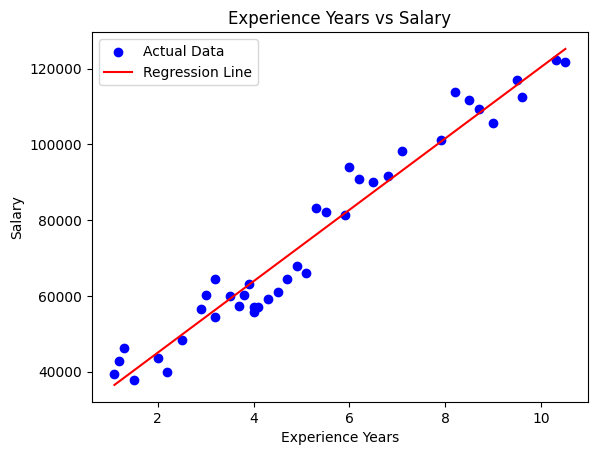

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot (actual data)
plt.scatter(X, y, color='blue', label='Actual Data')

# Create smooth range for line
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Predict values for the line
y_line = model.predict(X_range)

# Plot regression line
plt.plot(X_range, y_line, color='red', label='Regression Line')

# Labels and title
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience Years vs Salary")
plt.legend()

plt.show()